# Notebook 1 — MuMiN · Descriptive Analysis
## claims.csv (binary: misinformation / factual)

**Project:** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset:** `claims.csv` (MuMiN)  
**Goal:** reproduce NB1-style descriptive analysis directly on MuMiN claims, and export a clean file for NB2.


---
## Section 1 — Installation & Imports

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')


Imports OK


---
## Section 2 — Data Loading, Thematic Filtering, and Binary Labeling
Thematic filtering: cardiovascular diseases + diabetes (and associated terms).


In [5]:
claims_path = Path('claims.csv')
if not claims_path.exists():
    raise FileNotFoundError(f'File not found: {claims_path}')

claims_raw = pd.read_csv(claims_path, low_memory=False)

print(f'Raw rows loaded: {len(claims_raw)}')
print(f'Columns: {claims_raw.columns.tolist()}')


Raw rows loaded: 13205
Columns: ['claim', 'claim_en', 'verdict', 'train_mask', 'val_mask', 'test_mask']


In [6]:
# ── Label mapping: MuMiN uses verdict column with 'misinformation' / 'factual'
verdict_aliases = {
    'misinformation': 'misinformation',
    'misinfo':        'misinformation',
    'false':          'misinformation',
    'fake':           'misinformation',
    'factual':        'factual',
    'true':           'factual'
}
class_order  = ['misinformation', 'factual']
label_to_id  = {c: i for i, c in enumerate(class_order)}

In [8]:
health_keywords = [
    # Cardiovascular diseases
    "cardiovascular disease",
    "heart disease",
    "coronary artery disease",
    "ischemic heart disease",
    "myocardial infarction",
    "heart attack",
    "stroke",
    "ischemic stroke",
    "hypertension",
    "high blood pressure",
    "heart failure",
    "arrhythmia",

    # Cardiovascular symptoms
    "chest pain",
    "angina",
    "shortness of breath",
    "dyspnea",
    "palpitations",
    "fatigue",
    "dizziness",
    "syncope",
    "edema",

    # Cardiovascular risk factors
    "smoking",
    "tobacco use",
    "obesity",
    "BMI",
    "high cholesterol",
    "LDL",
    "HDL",
    "diabetes",
    "sedentary lifestyle",
    "family history",
    "age",

    # Cardiovascular treatments
    "statins",
    "beta-blockers",
    "antihypertensive drugs",
    "aspirin therapy",
    "angioplasty",
    "stent",
    "bypass surgery",

    # Cardiovascular tests
    "ECG",
    "electrocardiogram",
    "blood pressure",
    "cholesterol levels",
    "troponin",
    "echocardiogram",

    # Diabetes types
    "type 1 diabetes",
    "type 2 diabetes",
    "gestational diabetes",
    "prediabetes",

    # Diabetes symptoms
    "frequent urination",
    "polyuria",
    "excessive thirst",
    "polydipsia",
    "fatigue",
    "weight loss",
    "blurred vision",
    "slow wound healing",

    # Diabetes treatments
    "insulin",
    "metformin",
    "glucose-lowering drugs",
    "GLP-1 agonists",
    "lifestyle intervention",
    "diet control",
    "ALA",

    # Diabetes biomarkers
    "blood glucose",
    "fasting glucose",
    "HbA1c",
    "insulin level",
    "glucose tolerance test",

    # Diabetes complications
    "neuropathy",
    "nephropathy",
    "retinopathy",
    "cardiovascular disease",
    "diabetic foot ulcer",

    # General medical terms
    "risk factor",
    "prevalence",
    "incidence",
    "mortality",
    "clinical trial",
    "diagnosis",
    "treatment outcome",
    "patient",
    "hospital",
    "clinical study",
    "randomized controlled trial",
    "medical record",
    "electronic health records",
    "clinical notes",
    "medical report"
]



In [9]:

def normalize_text(x):
    x = '' if pd.isna(x) else str(x)
    x = x.lower()

    # remove accents and diacritics if exists
    x = unicodedata.normalize('NFD', x)
    x = ''.join(ch for ch in x if unicodedata.category(ch) != 'Mn')
    # normalize whitespace
    x = re.sub(r'\s+', ' ', x).strip()
    return x


keywords_norm = [
    normalize_text(k)
    for k in health_keywords
]

In [10]:

text_col = 'claim_en'
print(f'Text column used: {text_col}')

# ── Build searchable text and keep only thematic claims
claims_raw['_search_text'] = claims_raw[text_col].fillna('').astype(str)
claims_raw['_search_norm'] = claims_raw['_search_text'].map(normalize_text)

# Match complete thematic terms only, not substrings inside unrelated words.
# Example: "tia" should not match "potential", and "age" should not match "message".

keyword_patterns = [
    (k, re.compile(rf'(?<![a-z0-9]){re.escape(k)}(?![a-z0-9])'))
    for k in sorted(set(keywords_norm), key=len, reverse=True)
]

def find_health_words(text):
    return ', '.join(k for k, pat in keyword_patterns if pat.search(text))

claims_raw['health_word'] = claims_raw['_search_norm'].map(find_health_words)
mask_theme = claims_raw['health_word'].astype(bool)
claims_thematic = claims_raw[mask_theme].copy()

# ── Save filtered raw CSV for NB2
filtered_raw_path = Path('claims_cardio_diabete_filtered.csv')
claims_thematic.drop(columns=['_search_text', '_search_norm']).to_csv(filtered_raw_path, index=False)

# ── Binary labeling on filtered thematic subset
# Identify the verdict / label column
verdict_candidates = ['verdict', 'label', 'veracity', 'rating']
verdict_col = next((c for c in verdict_candidates if c in claims_thematic.columns), None)
if verdict_col is None:
    raise KeyError(f'No verdict column found. Available: {claims_thematic.columns.tolist()}')
print(f'Verdict column used: {verdict_col}')

df_claims = claims_thematic.copy()
df_claims['verdict_norm'] = df_claims[verdict_col].astype(str).str.strip().str.lower()
df_claims['label_name']   = df_claims['verdict_norm'].map(verdict_aliases)
df_claims = df_claims[df_claims['label_name'].isin(class_order)].copy()
df_claims['label'] = df_claims['label_name'].map(label_to_id).astype(int)

df_claims['text'] = df_claims[text_col].fillna('').astype(str)
df_claims['text'] = df_claims['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_claims = df_claims[df_claims['text'].astype(bool)].copy()
df_claims['text_len'] = df_claims['text'].str.len()

print(f'\nRaw rows (claims.csv)                : {len(claims_raw)}')
print(f'Thematic rows (cardio+diabetes)       : {len(claims_thematic)}')
print(f'Filtered raw CSV saved                : {filtered_raw_path}')
print(f'Filtered rows with binary labels      : {len(df_claims)}')
print(df_claims['label_name'].value_counts().reindex(class_order, fill_value=0).to_string())


Text column used: claim_en
Verdict column used: verdict

Raw rows (claims.csv)                : 13205
Thematic rows (cardio+diabetes)       : 354
Filtered raw CSV saved                : claims_cardio_diabete_filtered.csv
Filtered rows with binary labels      : 354
label_name
misinformation    337
factual            17


---
## Section 4 — Descriptive Visualizations

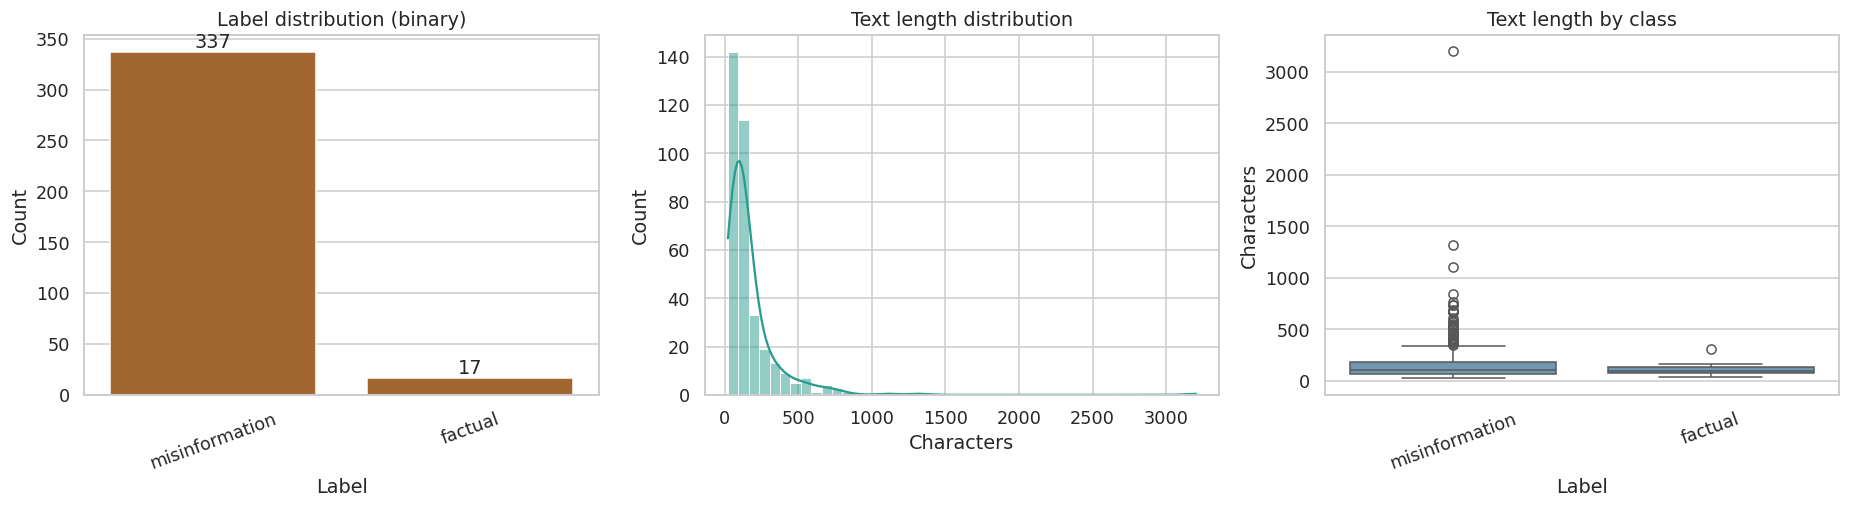

Saved: fig_nb1_mumin_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.countplot(data=df_claims, x='label_name', order=class_order, ax=axes[0], color='#b5651d')
axes[0].set_title('Label distribution (binary)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

sns.histplot(df_claims['text_len'], bins=45, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Text length distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

sns.boxplot(data=df_claims, x='label_name', y='text_len', order=class_order, ax=axes[2], color='#669bbc')
axes[2].set_title('Text length by class')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Characters')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()



---
## Section 6 — Export Files for NB2

In [13]:
baseline_ready = df_claims[['text', 'label_name', 'label', 'verdict_norm']].copy()
baseline_ready.to_csv('mumin_claims_cardio_diabete_baseline_ready.csv', index=False)

print('Saved: mumin_claims_cardio_diabete_baseline_ready.csv')


Saved: mumin_claims_cardio_diabete_baseline_ready.csv
